# 1. Введение

**Расчет цен на жилье в Москве**

В данном проекте решается задача регрессии по определению цены на жилье в Москве по его характеристикам (местонахождение, жил. площадь, этаж и прочее).
Используется датасет с Kaggle (hhttps://www.kaggle.com/datasets/egorkainov/moscow-housing-price-dataset).
Будут реализованы и протестированы три модели: RandomForestRegressor, CatBoost и нейронная сеть, созданная с помощью библиотеки tensorflow.keras
Также проведу анализ данных и сравню эффективность моделей.

# 2. Импорт библиотек

In [ ]:
!pip install catboost
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.1 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from category_encoders import TargetEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from scipy.stats import randint, uniform
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# 3. Анализ датасета

В данном датасете присутствуют цены и характеристики жилья в Москве на ноябрь 2023 года

In [ ]:
df = pd.read_csv('moscow_housing.csv')

df

,Price,Apartment type,Metro station,Minutes to metro,Region,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Renovation
0,6300000.0,Secondary,Опалиха,6.0,Moscow region,1.0,30.60,11.1,8.5,25.0,25,Cosmetic
1,9000000.0,Secondary,Павшино,2.0,Moscow region,1.0,49.20,20.0,10.0,6.0,15,European-style renovation
2,11090000.0,Secondary,Мякинино,14.0,Moscow region,1.0,44.70,16.2,13.1,10.0,25,Cosmetic
3,8300000.0,Secondary,Строгино,8.0,Moscow region,1.0,35.10,16.0,11.0,12.0,33,European-style renovation
4,6450000.0,Secondary,Опалиха,6.0,Moscow region,1.0,37.70,15.2,4.0,5.0,5,Without renovation
...,...,...,...,...,...,...,...,...,...,...,...,...
22671,4768792.0,New building,Котельники,8.0,Moscow region,0.0,31.75,13.0,5.0,4.0,17,Cosmetic
22672,5900000.0,New building,Домодедовская,25.0,Moscow region,1.0,31.60,10.1,12.2,11.0,15,Cosmetic
22673,3700000.0,New building,Котельники,30.0,Moscow region,0.0,18.00,15.0,8.1,17.0,17,Cosmetic
22674,5768869.0,New building,Жулебино,14.0,Moscow region,2.0,36.39,22.0,6.6,12.0,14,Cosmetic


Проверим общую информацию о датасете

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22676 entries, 0 to 22675
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             22676 non-null  float64
 1   Apartment type    22676 non-null  object 
 2   Metro station     22676 non-null  object 
 3   Minutes to metro  22676 non-null  float64
 4   Region            22676 non-null  object 
 5   Number of rooms   22676 non-null  float64
 6   Area              22676 non-null  float64
 7   Living area       22676 non-null  float64
 8   Kitchen area      22676 non-null  float64
 9   Floor             22676 non-null  float64
 10  Number of floors  22676 non-null  int64  
 11  Renovation        22676 non-null  object 
dtypes: float64(7), int64(1), object(4)
memory usage: 2.1+ MB


In [ ]:
print("\nОписательные статистики числовых признаков:")
df.describe()


Описательные статистики числовых признаков:


,Price,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors
count,2.267600e+04,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000,22676.000000
mean,3.612132e+07,11.888605,2.043129,71.966827,38.517953,12.594082,9.190466,16.556095
std,8.282561e+07,6.204457,1.523586,68.368608,38.124278,7.728074,7.549996,9.779297
min,1.150000e+06,0.000000,0.000000,6.000000,2.000000,1.000000,1.000000,1.000000
25%,7.068116e+06,7.000000,1.000000,37.400000,17.600000,8.600000,4.000000,11.000000
50%,1.134320e+07,11.000000,2.000000,53.300000,28.500000,10.600000,8.000000,16.000000
75%,2.479925e+07,15.000000,3.000000,77.140000,43.200000,14.500000,13.000000,20.000000
max,2.455020e+09,60.000000,12.000000,1117.000000,566.800000,122.000000,92.000000,97.000000


In [ ]:
print("\nКоличество уникальных значений в категориальных признаках:")
df.select_dtypes(include=['object']).nunique()


Количество уникальных значений в категориальных признаках:


,0
Apartment type,2
Metro station,547
Region,2
Renovation,4


Посмотрим распределение целевой переменной. На графике можно видеть, что большинство цен находится в нижнем ценовом диапазоне, что ожидаемо и показывает правдоподобность данного датасета

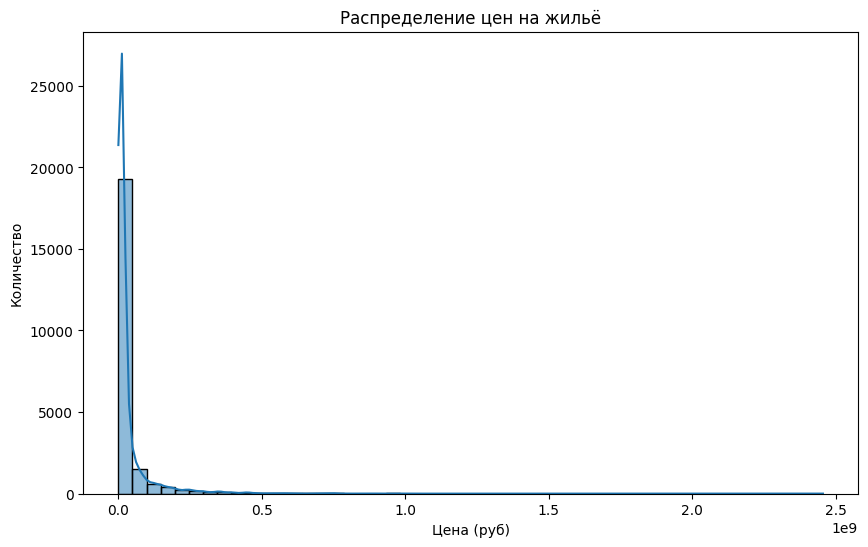

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=50, kde=True)
plt.title('Распределение цен на жильё')
plt.xlabel('Цена (руб)')
plt.ylabel('Количество')
plt.show()

Посмотрим на коррелияцию числовых признаков между собой
НА heatmap-е мы можем видеть, что на цену очень сильно влияют метраж и количество комнат. Время до метро тоже влияет (чем дольше идти до метро, тем дешевле будет квартира), но в сильно меньшей степени. Этажность здания и этаж жилья не влияет на цену

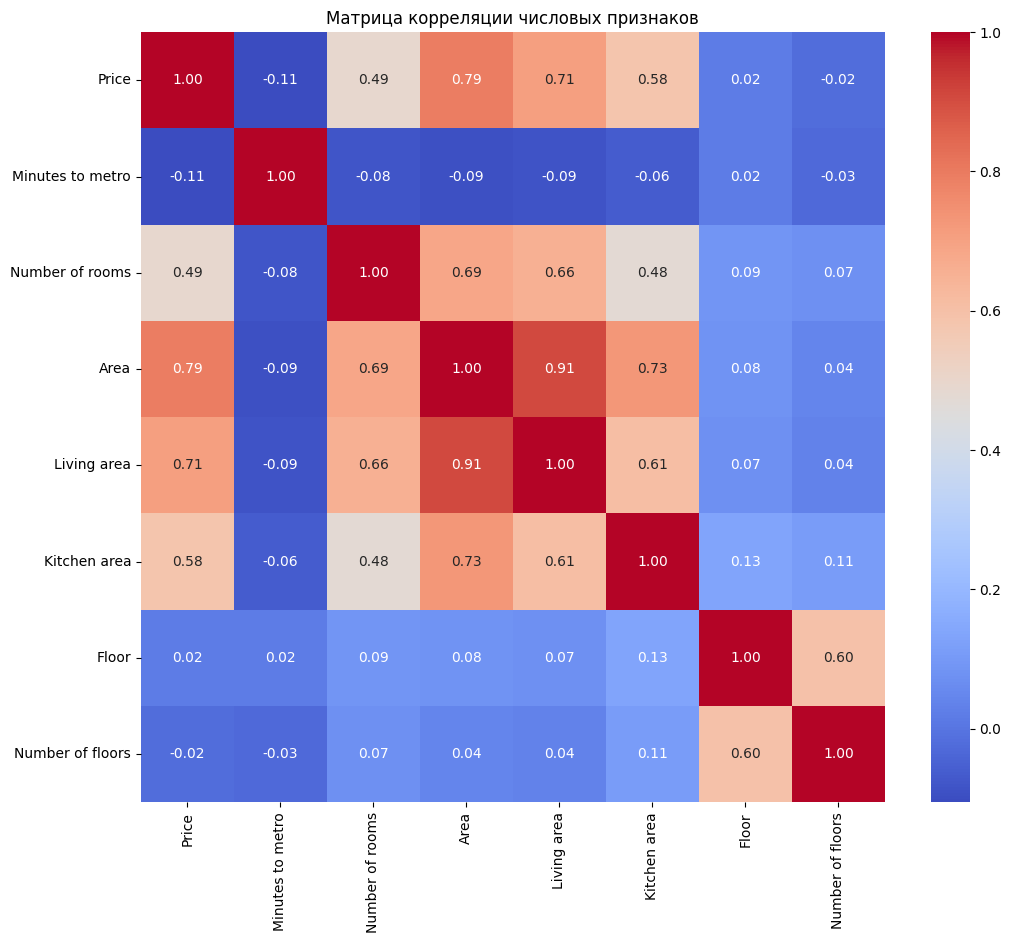

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
plt.figure(figsize=(12, 10))
sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Матрица корреляции числовых признаков')
plt.show()

Проанализируем распределение значений в категориальных признаках. На графиках можно увидеть, что большая часть рассматриваемого жилья является вторичкой в Москве. Причем по распределению станций метро, скорее всего большая часть из него находится в больших спальных районах с большим количеством квартир.


Категориальные признаки: ['Apartment type', 'Metro station', 'Region', 'Renovation']


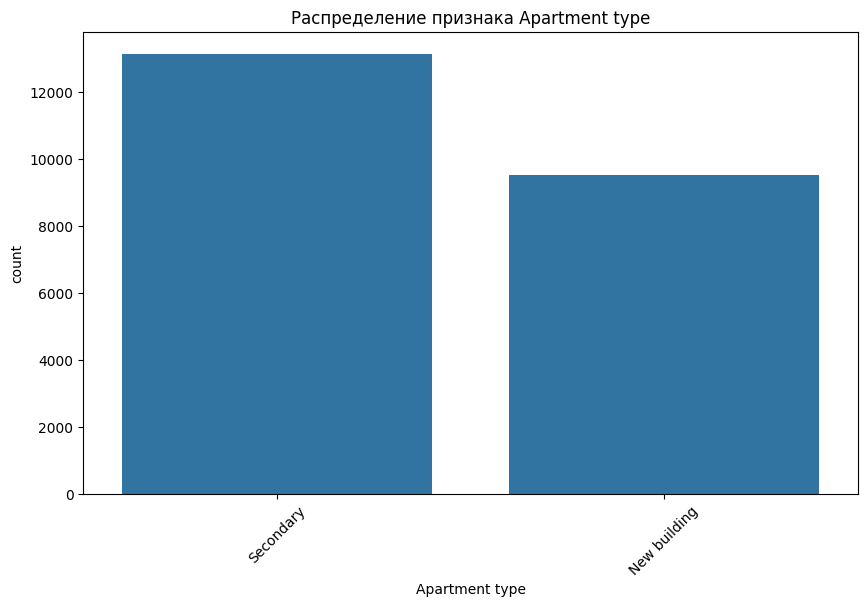

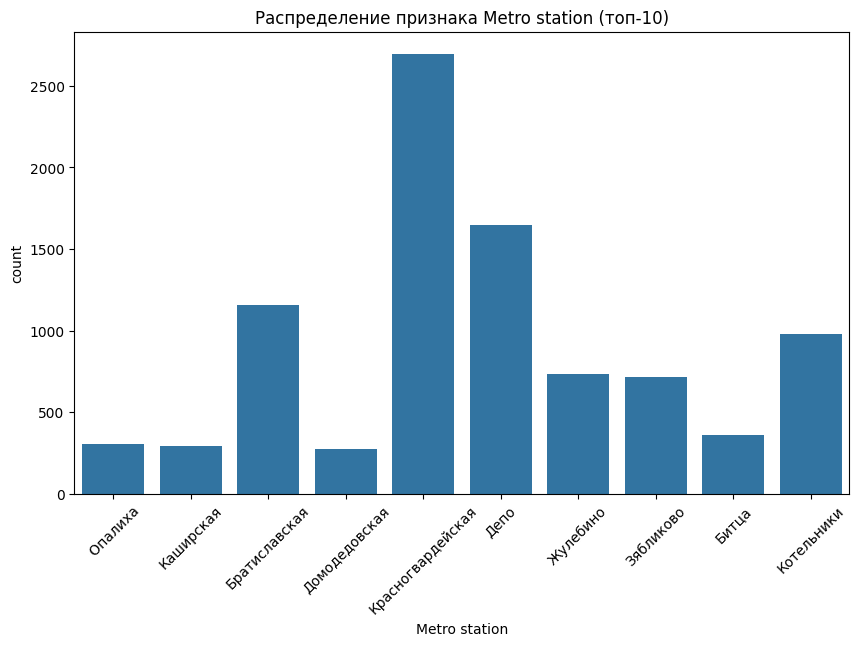

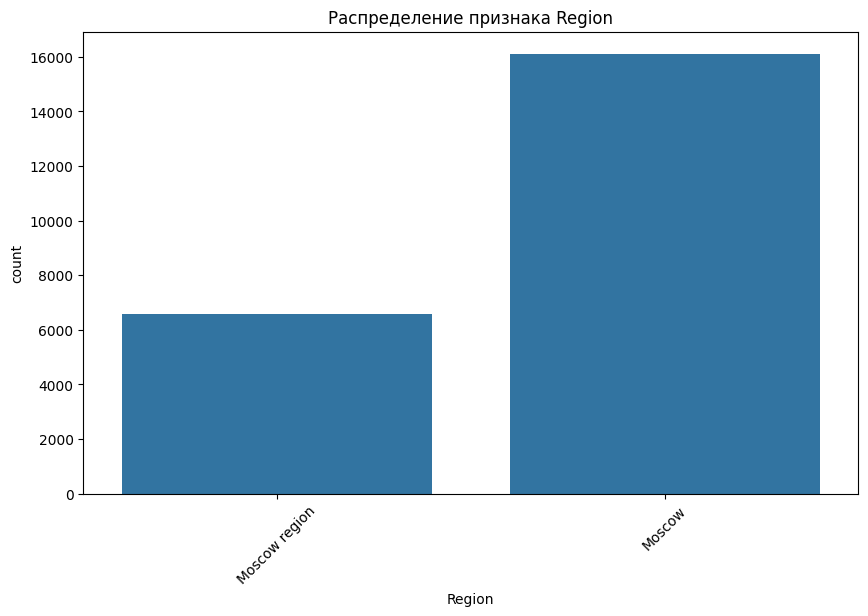

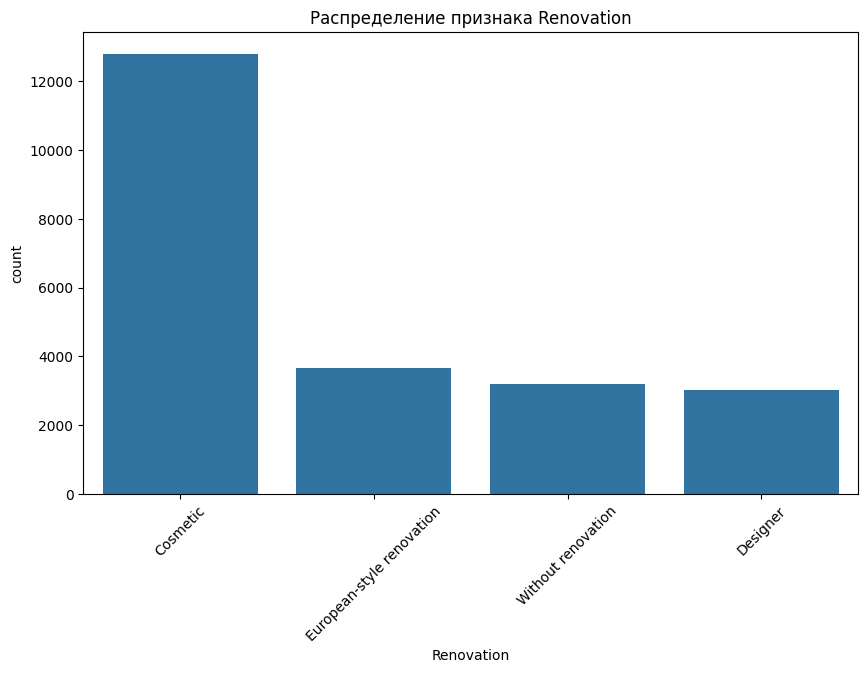

In [ ]:
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print("\nКатегориальные признаки:", categorical_features)

for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    if df[feature].nunique() > 10:  # Если уникальных значений много, покажем топ-10
        top_values = df[feature].value_counts().nlargest(10).index
        sns.countplot(data=df[df[feature].isin(top_values)], x=feature)
        plt.xticks(rotation=45)
        plt.title(f'Распределение признака {feature} (топ-10)')
    else:
        sns.countplot(data=df, x=feature)
        plt.xticks(rotation=45)
        plt.title(f'Распределение признака {feature}')
    plt.show()

# 4. Предобработка данных

Перед подачей данных в модели необходимо их предобработать. Сначала удаляются все дубликаты данных, если таковые имеются.

In [ ]:
print(f"\nКоличество строк до удаления дубликатов: {len(df)}")
df = df.drop_duplicates()
print(f"Количество строк после удаления дубликатов: {len(df)}")


Количество строк до удаления дубликатов: 22676
Количество строк после удаления дубликатов: 20841


Далее необходимо обработать пропущенные значения в случае их существования. Но в данном датасете, как можно увидеть ниже, они отсутствуют.

In [ ]:
print("\nПропущенные значения:")
print(df.isnull().sum())


Пропущенные значения:
Price               0
Apartment type      0
Metro station       0
Minutes to metro    0
Region              0
Number of rooms     0
Area                0
Living area         0
Kitchen area        0
Floor               0
Number of floors    0
Renovation          0
dtype: int64


Построим диаграммы выбросов по каждому числовому признаку.

Разберем результаты по каждому из признаков:

1. Price - выбросами являются элитные варианты жилья, которые стоят сильно дороже обычного. Но их достаточно много, поэтому оставим эти значения для обучения оценки стоимости и более дорогих вариантов
2. Minutes to metro, Number of rooms, Area, Living Area, Kitchen Area, Floor, Number of floors - есть выбросы, но они в пределах реалистичных значений. Также большая их часть объясняется вариантами элитного жилья

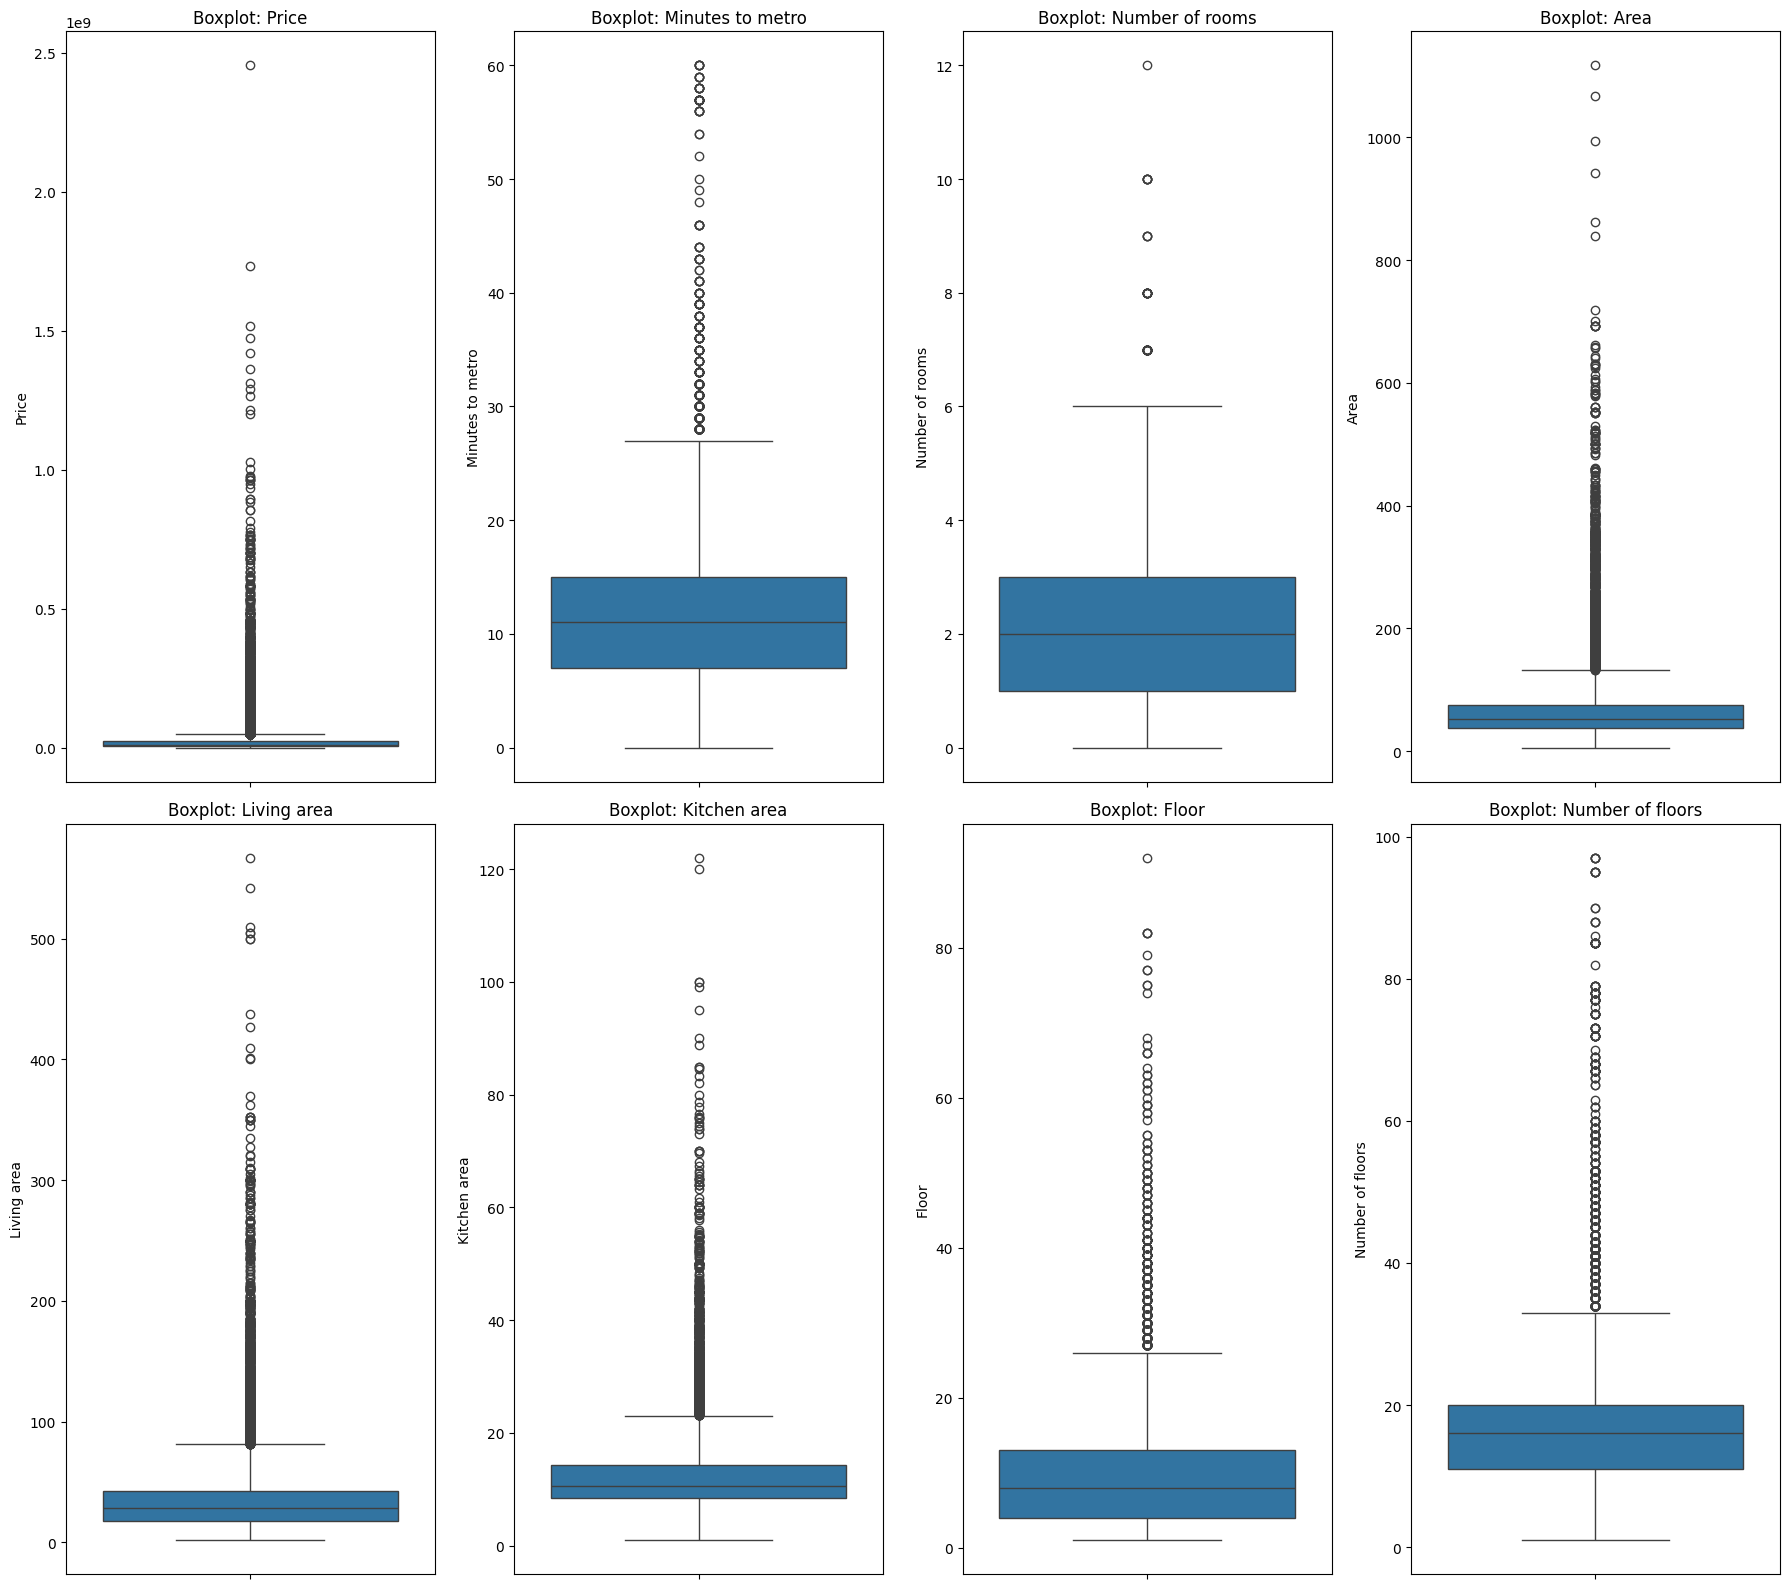

In [ ]:
numerical_f = df.iloc[:, [0, 3, 5, 6, 7, 8, 9, 10]]

fig, axes = plt.subplots(2, 4, figsize=(18, 16))
axes = axes.flatten()

for i in range(8):
    sns.boxplot(y=numerical_f.iloc[:, i], ax=axes[i])
    axes[i].set_title(f'Boxplot: {numerical_f.columns[i]}')

plt.tight_layout()
plt.show()

Разделяем на тренировочный и валидационный датасеты

In [ ]:
X = df.drop(['Price'], axis=1)
y = df['Price']
numerical_features.remove('Price')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (16672, 11)
Тестовая выборка: (4169, 11)


Проверим, есть ли в валидационном датасете станции метро, которые отсутствуют в тренировочном

In [ ]:
print(set(X_test['Metro station'].unique()) - set(X_train['Metro station'].unique()))

{' Подольск', ' Курьяново', ' Улица Горчакова', ' Каховская', ' Лианозово', 'Шоссе энтузиастов', ' Севастопольская', ' Красногвардейская', ' Трубная', 'Терехово (Мнёвники)', ' Пыхтино', ' Ясенево', ' Вешняки', ' Лесопарковая', 'Воробьевы горы', ' Нахимовский проспект', ' Новопеределкино', ' Депо', 'Лубянка'}


Такие действительно есть, но их достаточно мало. Для корректного обучения перенесем эти записи из валидационного в тренировочный датасет

In [ ]:
new_stations = set(X_test['Metro station'].unique()) - set(X_train['Metro station'].unique())

mask = X_test['Metro station'].isin(new_stations)

rows_to_move_X = X_test[mask]
rows_to_move_y = y_test[mask]

X_test = X_test[~mask].copy()
y_test = y_test[~mask].copy()

X_train = pd.concat([X_train, rows_to_move_X], axis=0)
y_train = pd.concat([y_train, rows_to_move_y], axis=0)

In [ ]:
X_train_processed = X_train.copy()
X_test_processed = X_test.copy()

Для обучения моделей, кроме CatBoost, необходимо закодировать категориальные признаки. Все признаки, кроме Metro station, кодируем с помощью One-Hot Encoding. Metro station же нельзя закодировать таким образом, так как этот признак обладает слишком высокой кардинальностью. Используем для кодировки Target Encoding

In [ ]:
other_cat_features = [col for col in categorical_features if col != 'Metro station']

target_encoder = TargetEncoder(handle_missing='value', handle_unknown='value')

X_train_processed = target_encoder.fit_transform(X_train[['Metro station']], y_train)
X_train_processed.columns = ['Metro_station_target_enc']

X_test_processed = target_encoder.transform(X_test[['Metro station']])
X_test_processed.columns = ['Metro_station_target_enc']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

train_cat_encoded = ohe.fit_transform(X_train[other_cat_features])
train_cat_encoded_df = pd.DataFrame(
    train_cat_encoded,
    columns=ohe.get_feature_names_out(other_cat_features),
    index=X_train.index
)

test_cat_encoded = ohe.transform(X_test[other_cat_features])
test_cat_encoded_df = pd.DataFrame(
    test_cat_encoded,
    columns=ohe.get_feature_names_out(other_cat_features),
    index=X_test.index
)

X_train_processed = pd.concat([X_train_processed, train_cat_encoded_df], axis=1)
X_test_processed = pd.concat([X_test_processed, test_cat_encoded_df], axis=1)

X_train_processed = pd.concat([
    X_train[numerical_features],
    X_train_processed
], axis=1)

X_test_processed = pd.concat([
    X_test[numerical_features],
    X_test_processed
], axis=1)

Применим скалирование ко всем данным, кроме тех, что закодированны с помощью One-Hot Encoding. Это критично важно для обучения нейронной сети, а также улучшит обучение остальных моделей

In [ ]:
scaler = StandardScaler()

numerical_features = [
 'Minutes to metro',
 'Number of rooms',
 'Area',
 'Living area',
 'Kitchen area',
 'Floor',
 'Number of floors',
 'Metro_station_target_enc']

X_train_processed[numerical_features] = scaler.fit_transform(X_train_processed[numerical_features])

X_test_processed[numerical_features] = scaler.transform(X_test_processed[numerical_features])

In [ ]:
print("Обработанные обучающие данные:")
print(f"Размерность: {X_train_processed.shape}")
display(X_train_processed.head())

print("\nОбработанные тестовые данные:")
print(f"Размерность: {X_test_processed.shape}")
display(X_test_processed.head())

Обработанные обучающие данные:
Размерность: (16693, 16)


,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Metro_station_target_enc,Apartment type_New building,Apartment type_Secondary,Region_Moscow,Region_Moscow region,Renovation_Cosmetic,Renovation_Designer,Renovation_European-style renovation,Renovation_Without renovation
12979,0.808574,-1.367797,-0.869710,-0.788567,-0.611260,-0.955490,-1.514813,-0.341197,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
13089,0.489208,-1.367797,-0.841655,-0.821937,-1.387865,-0.821748,-1.306625,-0.362312,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
13180,-0.628573,-0.695141,-0.493611,-0.449305,-0.343466,-0.153035,-0.161588,-0.489058,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
9361,-0.309207,0.650171,1.253153,1.544553,0.888390,-0.286778,-0.786153,0.327642,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0
14366,0.010159,-0.695141,-0.512782,-0.716265,0.071616,1.585617,-0.786153,-0.520979,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0



Обработанные тестовые данные:
Размерность: (4148, 16)


,Minutes to metro,Number of rooms,Area,Living area,Kitchen area,Floor,Number of floors,Metro_station_target_enc,Apartment type_New building,Apartment type_Secondary,Region_Moscow,Region_Moscow region,Renovation_Cosmetic,Renovation_Designer,Renovation_European-style renovation,Renovation_Without renovation
15438,1.127939,-0.022485,-0.112057,-0.132290,-0.222958,-0.688005,-0.577965,-0.491436,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
10700,-1.107622,2.668140,4.019732,5.910462,1.022288,-1.089233,-1.514813,2.514813,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0
5270,0.648891,-0.695141,-0.399002,-0.541073,0.754493,-0.554263,0.358883,-0.019321,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0
10125,-0.947939,1.995484,1.673984,2.545653,0.352801,-0.688005,-1.202530,4.115438,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0
16939,-0.468890,-0.695141,-0.427057,-0.388127,-0.303296,-0.153035,-0.265682,-0.500653,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


Проверим, что в результате предобработки данных у нас не появлось пропусков

In [ ]:
print(np.isnan(X_train_processed).sum())
print(np.isnan(X_test_processed).sum())
print(np.isnan(y_train).sum())
print(np.isnan(y_test).sum())

Minutes to metro                        0
Number of rooms                         0
Area                                    0
Living area                             0
Kitchen area                            0
Floor                                   0
Number of floors                        0
Metro_station_target_enc                0
Apartment type_New building             0
Apartment type_Secondary                0
Region_Moscow                           0
Region_Moscow region                    0
Renovation_Cosmetic                     0
Renovation_Designer                     0
Renovation_European-style renovation    0
Renovation_Without renovation           0
dtype: int64
Minutes to metro                        0
Number of rooms                         0
Area                                    0
Living area                             0
Kitchen area                            0
Floor                                   0
Number of floors                        0
Metro_station_target_

# 5. Обучение моделей
## Random Forest Regressor

### Оптимизация гиперпараметров:
Проведен RandomizedSearchCV по ключевым параметрам:
- n_estimators: 100-300 деревьев (компромисс между качеством и временем обучения)
- max_depth: 10-15 уровней (глубина достаточная для сложных зависимостей)
- min_samples_split: 2-10 (контроль переобучения для небольших групп)

In [ ]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_model = RandomForestRegressor(random_state=42, n_jobs=-1)
n_iter = 20

rf_search = RandomizedSearchCV(
    rf_model,
    rf_params,
    n_iter=n_iter,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
rf_search.fit(X_train_processed, y_train)

best_rf = rf_search.best_estimator_

print(f"Лучшие параметры: {rf_search.best_params_}")
print(f"Лучший MAE: {-rf_search.best_score_:.2f}")

y_pred_rf = best_rf.predict(X_test_processed)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE: {mae_rf:.2f}")
print(f"RMSE: {rmse_rf:.2f}")
print(f"R2: {r2_rf:.4f}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Лучшие параметры: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}
Лучший MAE: 8527548.98
MAE: 7728234.41
RMSE: 32564555.11
R2: 0.8081


**Вывод:** модель показала хорошую точность. Высокие значения MAE и RMSE связаны с высокими значениями целевого признака

## Нейронная сеть

### Обоснование конфигурации:

- BatchNorm: стабилизирует обучение при разных масштабах признаков
- Dropout: 20-30% для предотвращения переобучения
- 3 слоев достаточно для данного датасета. Если сделать больше, велик риск переобучения

In [ ]:
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_processed.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])

optimizer = Adam(learning_rate=0.005)
nn_model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

history = nn_model.fit(
    X_train_processed, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    verbose=1)



/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 7715828216627200.0000 - mae: 33432314.0000 - val_loss: 7615909023711232.0000 - val_mae: 32874126.0000
Epoch 2/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 8137654134636544.0000 - mae: 34548104.0000 - val_loss: 7559214381662208.0000 - val_mae: 32734476.0000
Epoch 3/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7918528124420096.0000 - mae: 34657096.0000 - val_loss: 7410632135540736.0000 - val_mae: 32064808.0000
Epoch 4/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7868348947759104.0000 - mae: 33224482.0000 - val_loss: 7143308539199488.0000 - val_mae: 30686504.0000
Epoch 5/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 7224153782353920.0000 - mae: 31633482.0000 - val_loss: 6801444174823424.0000 - val_mae: 29376286.0000
Epoch 6/100
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6415963343814656.0000 - mae: 28912058.0000 - val_loss: 6078635538644992.0000 - val_mae: 25255816.0000
Epoch 7/100
209/209 ━━

130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Нейронная сеть:
MAE: 11610592.72
RMSE: 37721112.11
R2: 0.7425


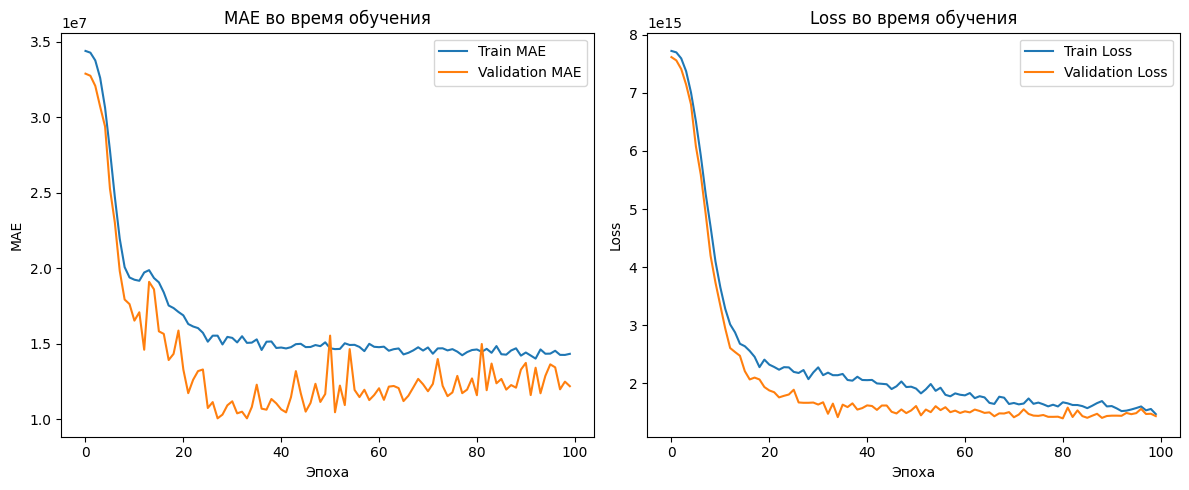

In [ ]:
y_pred_nn = nn_model.predict(X_test_processed).flatten()

mae_nn = mean_absolute_error(y_test, y_pred_nn)
rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("\nНейронная сеть:")
print(f"MAE: {mae_nn:.2f}")
print(f"RMSE: {rmse_nn:.2f}")
print(f"R2: {r2_nn:.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('MAE во время обучения')
plt.ylabel('MAE')
plt.xlabel('Эпоха')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss во время обучения')
plt.ylabel('Loss')
plt.xlabel('Эпоха')
plt.legend()

plt.tight_layout()
plt.show()

**Вывод:** Нейронная сеть сработала неплохо, но ей недостает данных, чтобы догнать по эффективности RFR

## CatBoost

Главной особенностью этой модели является возможность работать с незакодированными категориальными признаками

### Оптимизация гиперпараметров:
- iterations: 500-1500 (достаточно для сходимости)
- depth: 6-10 (оптимально для выявления нелинейностей)
- learning_rate: 0.01-0.3 (адаптивный подбор скорости)
- l2_leaf_reg: 1-10 (защита от переобучения)

In [ ]:
print("\nНастройка CatBoost...")
cat_features_indices = [X_train.columns.get_loc(col) for col in categorical_features]

cb_params = {
    'iterations': randint(500, 1500),
    'depth': randint(4, 10),
    'learning_rate': uniform(0.01, 0.3),
    'l2_leaf_reg': randint(1, 10),
    'random_strength': randint(1, 20)
}

cat_model = CatBoostRegressor(random_seed=42, verbose=0)

cb_search = RandomizedSearchCV(
    cat_model,
    cb_params,
    n_iter=20,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

cb_search.fit(
    X_train,
    y_train,
    cat_features=cat_features_indices,
    verbose=1
)

best_cb = cb_search.best_estimator_

print(f"\nЛучшие параметры: {cb_search.best_params_}")
print(f"Лучший MAE: {-cb_search.best_score_:.2f}")

y_pred_cb = best_cb.predict(X_test)

mae_cat = mean_absolute_error(y_test, y_pred_cb)
rmse_cat = np.sqrt(mean_squared_error(y_test, y_pred_cb))
r2_cat = r2_score(y_test, y_pred_cb)

print("\nCatBoostRegressor:")
print(f"MAE: {mae_cat:.2f}")
print(f"RMSE: {rmse_cat:.2f}")
print(f"R2: {r2_cat:.4f}")


Настройка CatBoost...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
0:	learn: 77579716.2887026	total: 75.5ms	remaining: 1m 38s
1:	learn: 74334037.8188670	total: 103ms	remaining: 1m 6s
2:	learn: 71343858.2378722	total: 128ms	remaining: 55.4s
3:	learn: 68723671.8402436	total: 157ms	remaining: 51.1s
4:	learn: 66358496.3165169	total: 179ms	remaining: 46.6s
5:	learn: 64161497.7328893	total: 207ms	remaining: 44.9s
6:	learn: 61980809.0254423	total: 231ms	remaining: 42.8s
7:	learn: 60026516.6507128	total: 255ms	remaining: 41.3s
8:	learn: 58187634.7628191	total: 280ms	remaining: 40.3s
9:	learn: 56503721.3694826	total: 304ms	remaining: 39.4s
10:	learn: 54929115.2462064	total: 330ms	remaining: 38.8s
11:	learn: 53446677.6133631	total: 353ms	remaining: 38s
12:	learn: 52055605.6159588	total: 375ms	remaining: 37.3s
13:	learn: 50799194.8937097	total: 398ms	remaining: 36.7s
14:	learn: 49615957.0140204	total: 425ms	remaining: 36.6s
15:	learn: 48696814.3591797	total: 468ms	remaining: 37.

**Вывод:** благодаря своим возможностям по выявлению сложных зависимостей и работе с категориальными признаками напрямую CatBoost показал хороший результат. Но он несколько недотягивает до более простого RFR, что скорее всего происходит из-за малого количества данных для данной модели

# 6. Анализ результатов

,Model,MAE,RMSE,R2
0,Random Forest,7.728234e+06,3.256456e+07,0.808098
1,CatBoost,8.976251e+06,3.500437e+07,0.778266
2,Neural Network,1.161059e+07,3.772111e+07,0.742512


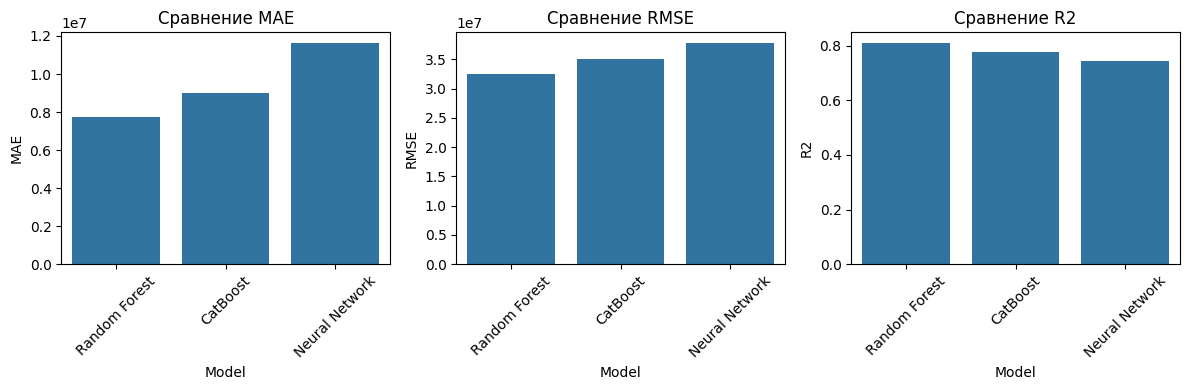

In [ ]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'CatBoost', 'Neural Network'],
    'MAE': [mae_rf, mae_cat, mae_nn],
    'RMSE': [rmse_rf, rmse_cat, rmse_nn],
    'R2': [r2_rf, r2_cat, r2_nn]
})

display(results)

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
sns.barplot(x='Model', y='MAE', data=results)
plt.title('Сравнение MAE')
plt.xticks(rotation=45)

plt.subplot(1, 3, 2)
sns.barplot(x='Model', y='RMSE', data=results)
plt.title('Сравнение RMSE')
plt.xticks(rotation=45)

plt.subplot(1, 3, 3)
sns.barplot(x='Model', y='R2', data=results)
plt.title('Сравнение R2')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

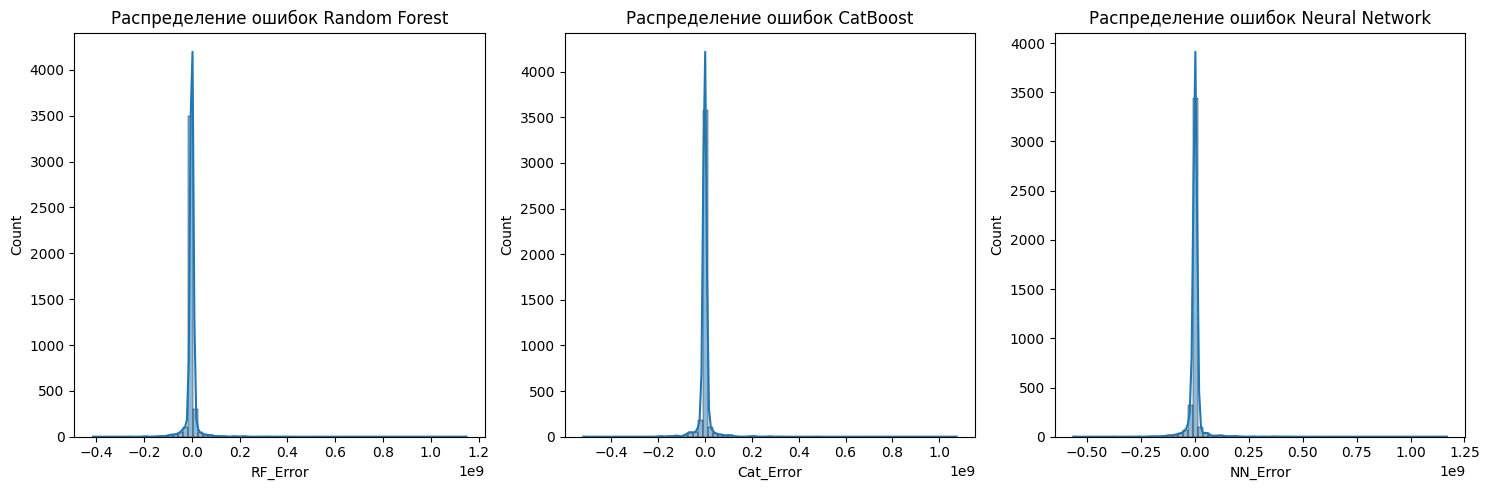

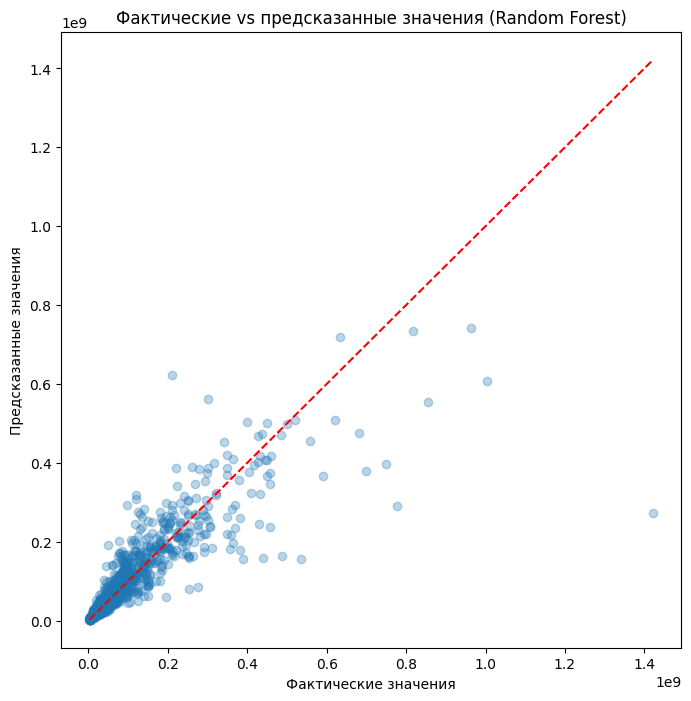

In [ ]:
results_df = pd.DataFrame({
    'Actual': y_test,
    'RF_Predicted': y_pred_rf,
    'Cat_Predicted': y_pred_cb,
    'NN_Predicted': y_pred_nn
})

results_df['RF_Error'] = (results_df['Actual'] - results_df['RF_Predicted'])
results_df['Cat_Error'] = results_df['Actual'] - results_df['Cat_Predicted']
results_df['NN_Error'] = results_df['Actual'] - results_df['NN_Predicted']

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(results_df['RF_Error'], kde=True, bins=75)
plt.title('Распределение ошибок Random Forest')

plt.subplot(1, 3, 2)
sns.histplot(results_df['Cat_Error'], kde=True, bins=75)
plt.title('Распределение ошибок CatBoost')

plt.subplot(1, 3, 3)
sns.histplot(results_df['NN_Error'], kde=True, bins=75)
plt.title('Распределение ошибок Neural Network')

plt.tight_layout()
plt.show()

best_model = results.loc[results['R2'].idxmax(), 'Model']
if best_model == 'Random Forest':
    y_pred_best = y_pred_rf
elif best_model == 'CatBoost':
    y_pred_best = y_pred_cb
else:
    y_pred_best = y_pred_nn

plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred_best, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Фактические значения')
plt.ylabel('Предсказанные значения')
plt.title(f'Фактические vs предсказанные значения ({best_model})')
plt.show()

### Цифры
1. Random Forest (RFR) показал наилучшие результаты по всем метрикам:
- MAE: 7.73 млн (на 14% лучше CatBoost)
- RMSE: 32.56 млн (на 7% лучше CatBoost)
- R²: 0.808 (на 3% лучше CatBoost)

2. CatBoost занял второе место:
- Проигрыш RFR по MAE ∼1.25 млн руб
- Худшая стабильность (высокий RMSE)

3. Нейронная сеть показала наихудшие результаты:
- MAE на 50% хуже RFR
- Не такая высокая объясняющая способность (R²=0.74)

### Вероятные причины превосходства Random Forest
1. Датасет содержит относительно "четкие" правила ценообразования зависящие в первую очередь от площади. Район также обычно влияет однозначным образом на цену

2. RFR лучше сглаживает высокие значения цен на элитное жилье в своем обучении

3. Избыточная гибкость бустинга CatBoost приводит к влиянию цен на элитное жилье, как шумов

4. Нейросети недостает данных для более эффективного обучения


**Вывод:** Random Forest показал лучшие результаты благодаря оптимальному соответствию между сложностью модели и структурой данных. Его дискретная природа лучше считывает "ступенчатые" зависимости на рынке недвижимости, где цена часто определяется набором четких правил и пороговых значений.